# Benchmark de modelos de ML para la detección de fraude con tarjetas de crédito

### Resumen

En este trabajo estudiamos el problema de transacciones fraudulentas con tarjetas de crédito y llevamos a cabo un análisis formal y una evaluación del desempeño de un abanico de técnicas de aprendizaje automático supervisado y no supervisado ampliamente utilizados para la detección de dicha clase de fraudes. Para ello, en primera instancia, realizamos el preprocesamiento de un conjunto de datos abiertos disponibles en la comunidad en línea [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?select=creditcard.csv) con el fin de obtener información relevante de los mismos y analizamos los problemas asociados intrínsecamente al dataset que afectan la detección de fraude [[1](https://www.sciencedirect.com/science/article/abs/pii/S2214212618304216), [2](https://www.aaai.org/Papers/Workshops/2000/WS-00-05/WS00-05-003.pdf), [3](https://ieeexplore.ieee.org/abstract/document/7376606)] (escasez de datos, heterogeneidad de datos, estacionariedad, arranque en frío y desequilibrio de datos) y por otra parte, usamos dicho dataset para realizar el entrenamiento de los algoritmos de aprendizaje supervisado. A continuación, generamos una secuencia de números pseudoaleatorios con una semilla determinada utilizando las librerías disponibles en Python con el objetivo de reproducir los experimentos y poder generar de esa forma un criterio de comparación del rendimiento de los distintos algoritmos de aprendizaje automático.

**Palabras clave**: detección de fraude, aprendizaje automático, aprendizaje supervisado y no supervisado, preprocesamiento, desequilibrio de datos, entrenamiento, pseudoaleatorios, Python.

### 1. Introducción

El comercio electrónico sin lugar a dudas constituye en la actualidad un cambio de paradigma en los negocios. Además del diseño e implementación de plataformas de e-commerce eficientes en donde efectuar la compraventa de bienes y servicios mediante la utilización de dirvesos dispositivos como las computadoras personales, las tablets y los celulares, la columna vertebral a la hora de realizar operaciones comerciales de dicha índole lo conforman el uso de tarjetas de crédito sin las cuales carecería de sentido el intercabio electrónico. Por este motivo, en los últimos años ha habido un incremento explosivo en las transacciones con tarjetas de crédito y esto ha traído como consecuencia un cambio en la dinámica de los negocios. Si bien la era del Big Data y de las nuevas tecnologías establecen una oportunidad sin precedentes en cuanto a la mejora de la calidad de vida y bienestar social, no quedan absolutamente exentas de problemas, lo que genera ineficiencias en su implementación. En el caso particular de las transacciones con tarjetas de crédito, un problema no menor lo conforman los fraudes dado que traen aparejadas en el corto plazo pérdidas financieras significativas$^1$ que afectan no sólo bancos y comerciantes sino también a los clientes individuales mientras que por otro lado en el largo plazo pueden impactar negativamente sobre la imagen de una compaĩa ocasionando que el cliente objeto del fraude desconfíe del negocio y elija a un competidor [[4](https://www.sciencedirect.com/science/article/abs/pii/S095741741400089X)].

Aunque el concepto de fraude, tan antigüo como la humanidad misma es mucho más abarcativo que las transacciones fraudulentas, en este trabajo nos enfocamos concretamente en estas últimas. Para evitar la perpetración de fraudes se siguen dos tipos de acciones, prevención y detección de fraude [[5](https://www.semanticscholar.org/paper/Adaptive-Machine-Learning-for-Credit-Card-Fraud-Pozzolo-Bontempi/bcfbf068dff507b9ef11240e69f96d24f5d89fc1)]. La diferencia entre ambas es que la primera es una acción a priori, es decir, se trata de anticipar el fraude bloqueándolo en su origen, mientras que la segunda es un proceso a posteriori, es decir, partiendo de un conjunto de datos de transacciones con tarjetas de crédito se identifica si una nueva operación hailitada pertenece o no a la clase de transacciones frudulentas o genuinas. Todo Sistema de Detección de Fraude (FDS) debe superar de base dos problemas elementales: eficiencia y rentabilidad. Lo primero hace referencia a que dicho sistema debe poder determinar eficientemente si una transacción es o no fraudulenta y lo segundo se refiere a que el costo por detección no puede ser mayor a la pérdida debida a los fraudes. Aquí es donde las técnicas de aprendizaje automatico se vuelven atractivas para abordar el problema dado que son altamente eficientes y de bajo costo comparativamente a lo que sería con la intrvención de expertos (no se excluyen estos últmos sino que se complementan con los métodos de ML disminuyéndo significativamente los esfuerzos humanos). Por otra parte, los algoritmos de aprendizaje automático tienen preponderancia en la detección de transacciones fraudulentas dado que las técnicas supervisadas pueden entrenarse mediante el análisis de transacciones pasadas para aprender de los patrones fraudulentos y por otro lado, los algoritmos no supervisados permiten resolver el problema de cambio de comportamiento de estafadores para desarrollar nuevos patrones de fraude [[6](https://www.sciencedirect.com/science/article/abs/pii/S0020025519304451)]. En relación a esto, se han llevado a cabo innumerables esfuerzos y contibuciones para aplicar las técnicas de aprendizaje automático a la detección de transacciones fraudulentas como por ejemplo Convolutional Neural Networks (CNN) [[7](https://link.springer.com/chapter/10.1007/978-3-319-46675-0_53)], Random Forest [[8](https://ieeexplore.ieee.org/abstract/document/8361343)], y otras métodos muy innovadores [[1](https://www.sciencedirect.com/science/article/abs/pii/S2214212618304216)]. En línea a esto, este trabajo nos porponemos realizar un estudio comparativo de los distintos algoritmos de aprendizaje automático tanto supervisados como no supervisados evaluando su rendimiento en la aplicación de detección de transacciones fraudulentas [[9](https://arxiv.org/abs/1904.10604), [6](https://www.sciencedirect.com/science/article/abs/pii/S0020025519304451)], para ello en la primera sección analizamos los distintos trabajos relacionados y el estado de arte de las técnicas existentes, sus aspectos positivos y negativos y los problemas asociados. A continuación, presentamos el diseño experimental, los resultados obtenidos de la evaluación del rendimiento de los distintos métodos y la interpretación de los mismos y por último derivamos las conlusiones del trabajo.

$^1$Según un análisis llevado a cabo por la entidad “Euromonitor International”, el costo financiero asociado a los fraudes a aumentado en el área de Europa, Oriente Medio y África (EMEA) de 2006 a 2016 mientras que la “Asociación Estadounidense de Examinadores de Fraudes” descubrió que el 15 % de fraudes corresponden de alguna forma a las transacciones con tarjetas de crédito lo que representa un 80 % del valor financiero total [[1](https://www.sciencedirect.com/science/article/abs/pii/S2214212618304216)].

In [2]:
# Importamos las librerias
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## Selección e importación de datos

El dataset seleccionado correponde a un conjunto de transacciones llevadas a cabo por propietarios de tarjetas de créditos en Europa ejecutadas en dos dos días de 2013.

In [3]:
# Cargamos el dataset
fraude_df = pd.read_csv("creditcard.csv")
# Imprimimos por pantalla las primeras líneas
fraude_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Imprimimos por pantalla las últimas líneas
fraude_df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
# Número de filas y columnas
fraude_df.shape

(284807, 31)

**¿Existen valores no nulos en el dataset?**

In [6]:
#Tipo de datos y cantidad de valores no nulos
fraude_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Análisis exploratorio de datos

**¿Qué porcentaje del total de transacciones representan fraudes y no fraudes?**

**¿Existe un desbalance en el dataset?**

En primer lugar debemos realizar un preprocesamiento de datos, lo que nos lleva en primera instancia a determinar el número de transacciones fraudulentas y no fraudulentas de nuestro dataset (binarización de clases).

Text(0.5, 1.0, 'Comparacion de numero de transacciones fraudulentas (1) vs. no fraudulentas (0)')

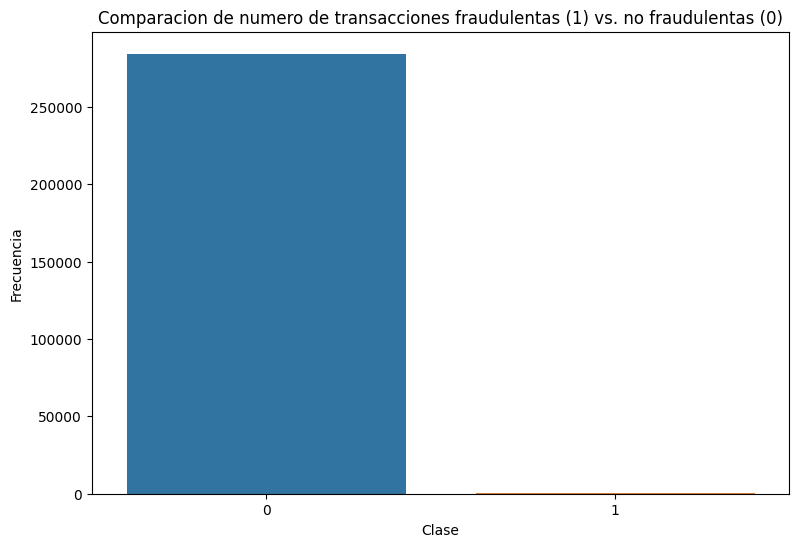

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
ax = sns.countplot(data=fraude_df, x="Class")

ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
ax.set_title("Comparacion de numero de transacciones fraudulentas (1) vs. no fraudulentas (0)")

Observamos que existe un alto grado de desequilibrio en los datos (lo que requiere un tratamiento especial). La proporción de transacciones no fraudulentas es 492 de 284,807 lo que corresponde a un 0.17%. 

In [8]:
# T := número total de transacciones, 
# T_plus := número de transacciones legítimas,
# T_minus := número de transacciones fraudulentas

T = fraude_df["Class"].count()
T_plus = fraude_df["Class"].value_counts()[0]
T_minus = fraude_df["Class"].value_counts()[1]

print("El porcentaje de transacciones legitimas es:", (T_plus/T)*100, "%")
print("El porcentaje de transacciones legitimas es:", (T_minus/T)*100, "%")

El porcentaje de transacciones legitimas es: 99.82725143693798 %
El porcentaje de transacciones legitimas es: 0.1727485630620034 %


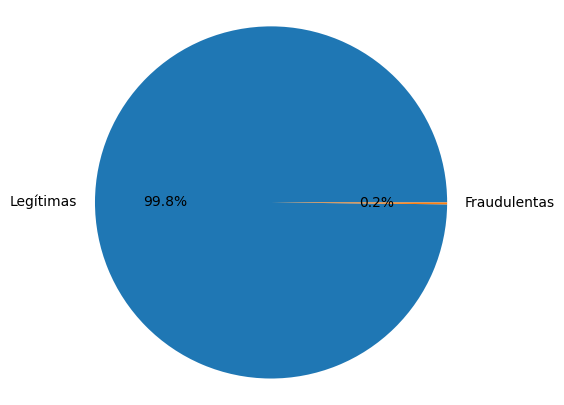

In [9]:
# Gráfico de torta

fig, ax = plt.subplots(figsize=(5,5))

labels = "Legítimas", "Fraudulentas"
porcentajes = [(T_plus/T)*100, (T_minus/T)*100]
explode = (0, 0.1, 0, 0)

ax.pie(porcentajes, labels=labels,autopct='%1.1f%%')
ax.axis('equal')

plt.show()

**¿Qué variables requieren de un análisis especial y cuáles son los datos relevantes de las mismas?**

Dado que se ha anonimizado la información mediante un análisis de componentes principales (PCA) del conjunto de datos para salvaguardar la confidencialidad, excepto en lo relativo al tiempo y al monto, que contienen respectivamente los segundos transcurridos entre cada transacción y la primera en el conjunto de datos y el importe de la transacción subyacente, debemos analizar con mayor profundidad estas dos variables.

In [10]:
# Variables que requieren un análisis especial
tiempo_parametros = fraude_df["Time"].describe()
cantidad_parametros = fraude_df["Amount"].describe()

print("Datos relevantes de la variable intervalo temporal:")
print(tiempo_parametros)
print("\n")
print("Datos relevantes de la variable importe:")
print(cantidad_parametros)

Datos relevantes de la variable intervalo temporal:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


Datos relevantes de la variable importe:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


Como puede observarse de los gráficos siguientes, la distribución del importe se encuentra muy sesgada a la derecha dado que una parte muy pequeña de las transacciones se acerca al máximo monto que corresponde a \\$25691.16, el valor medio para esta distribución es \\$88.35. Por el contrario, a diferencia de la distribución del importe la distribución temporal es bimodal, esto se debe a que se da una merma la actividad de las transacciones aproximadamente 27.78 hs. desde la primera transacción, lo que hace razonable la suposición de que la baja en el volumen de transacciones se dio durante la noche dado que los usuarios duermen en esta etapa del día y los niveles de actividad caen.

Text(0.5, 1.0, 'Distribución del importe')

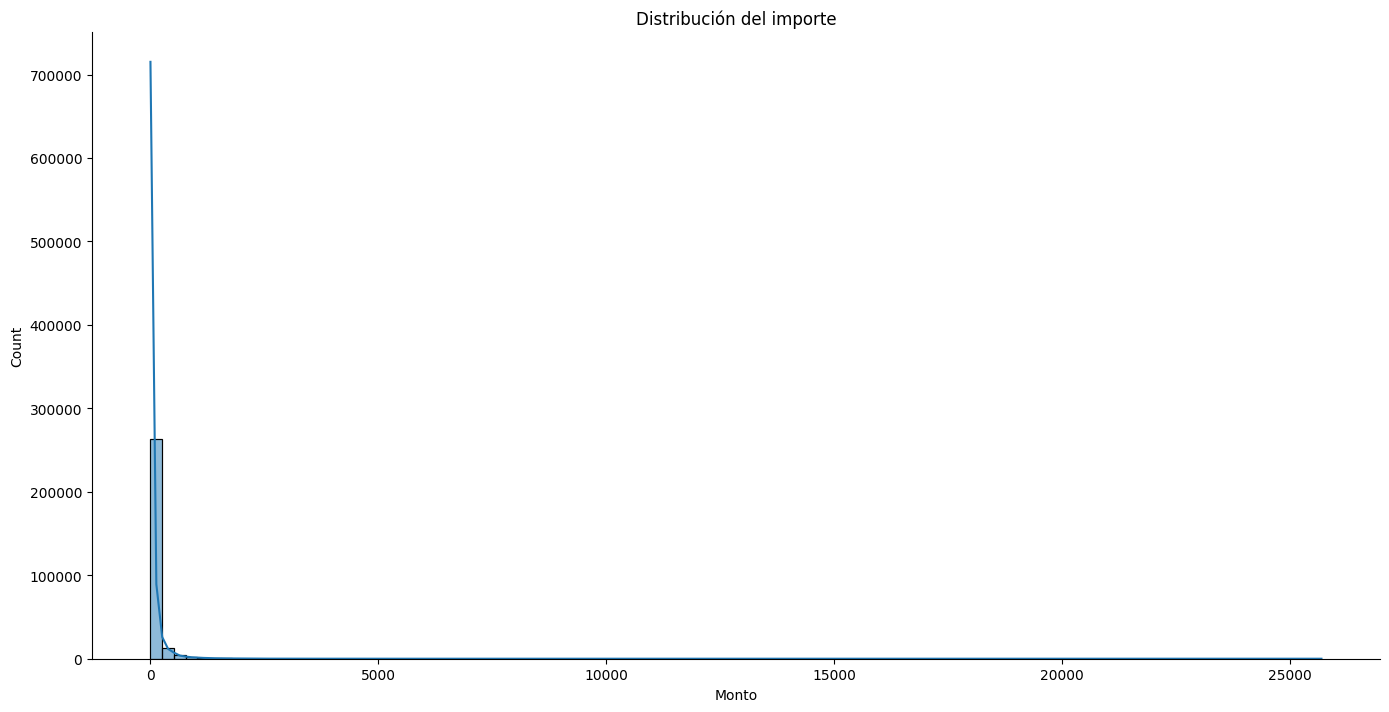

In [11]:
sns.displot(data=fraude_df, x="Amount", height=7, aspect=2.0, bins=100, kde=True)

plt.xlabel("Monto")
plt.title("Distribución del importe")

Text(0.5, 1.0, 'Distribucion temporal')

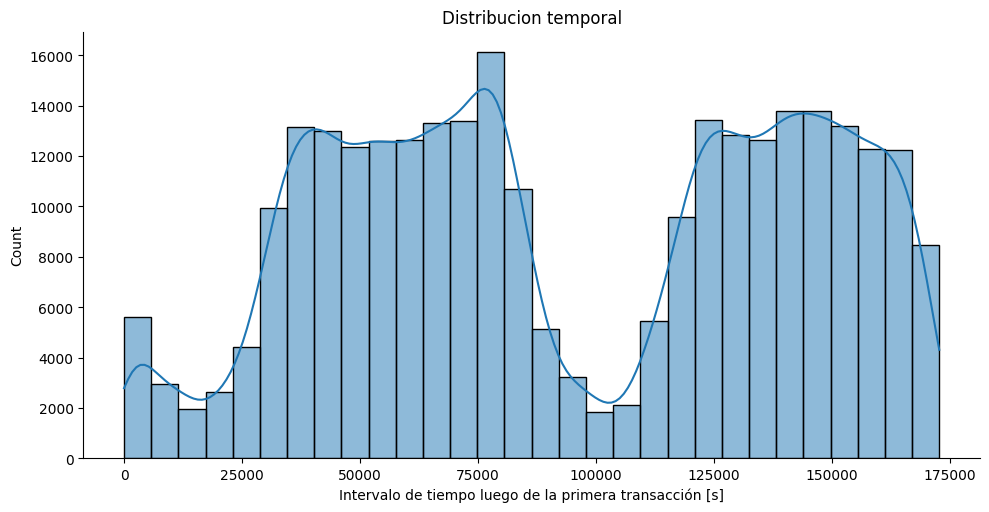

In [12]:
sns.displot(data=fraude_df, x="Time", height=5, aspect=2.0, bins=30, kde=True)

plt.xlabel("Intervalo de tiempo luego de la primera transacción [s]")
plt.title("Distribucion temporal")

**¿Existen correlaciones fuertes entre las componentes reducidas?**

El resto de las variables se obtienen de un análisis de componentes principales (PCA), método que da lugar a un conjunto de variables no correlacionadas y que permite reducir la dimensionalidad.

Para corroborar que no existen correlaciones significativas entre las componentes reducidas (particularmente con la característica de clase) calculamos la matriz de correlación

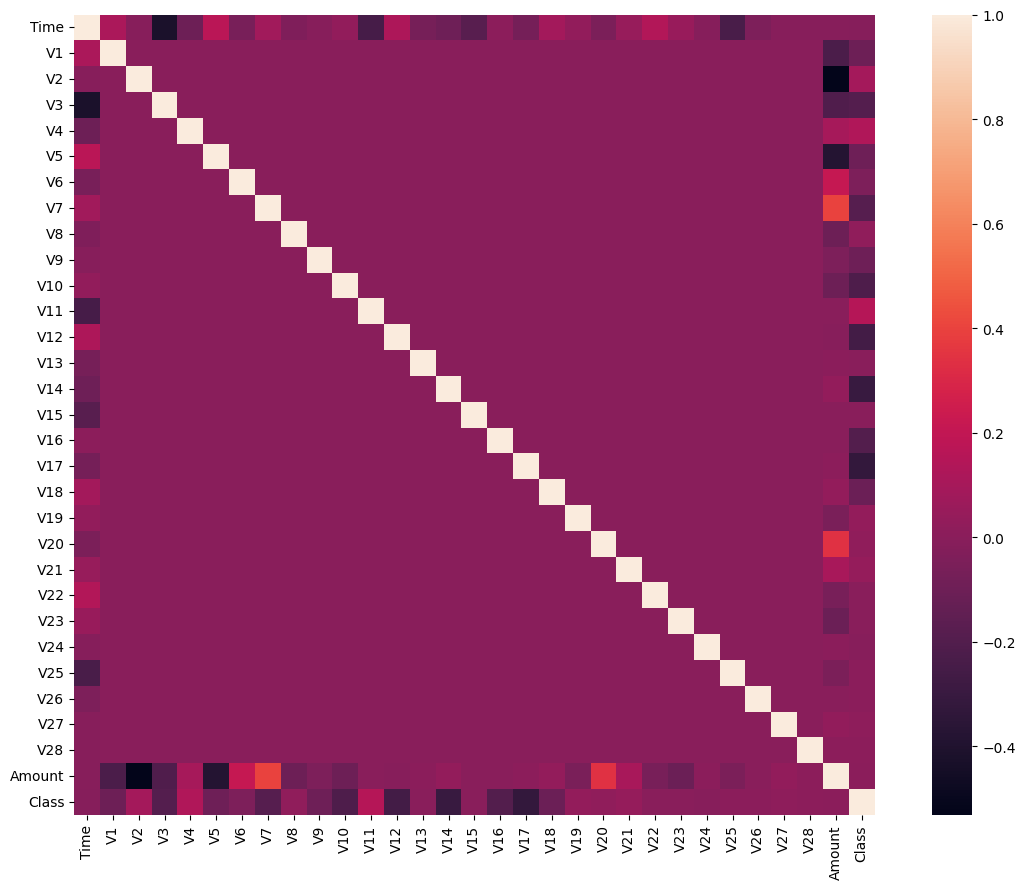

In [13]:
corr_df = fraude_df.corr()
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(corr_df, vmax=1.0, square = True)
plt.tight_layout()

Dado que las caracteristicas principales no presentan correlaciones fuertes entre ellas, no es necesario eliminar ninguna de las variables.

Se presentan a continuación las distribuciones de las 28 características V1, V2, ..., V28 en forma de histogramas.Como era de esperarse, incluso si se trata de un dataset transformado por PCA, las variables no se distribuyen normalmente. En los gráficos se observa de que algunas de las distribuciones están segadas hacia la izquierda y otras hacia la derecha.

En total son 31 variables, de las cuales 28 son las variables características y el resto corresponden a el tiempo, el monto y la clase. De todas ellas, las únicas que no han sido transformadas por PCA son el tiempo y el monto y por otro lado,la variable clase corresponde a nustra variable objetivo que es la única variable categórica.

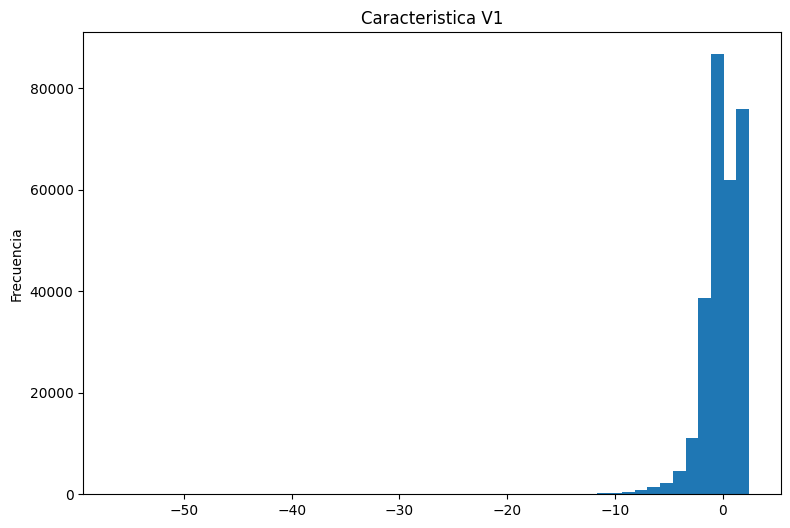

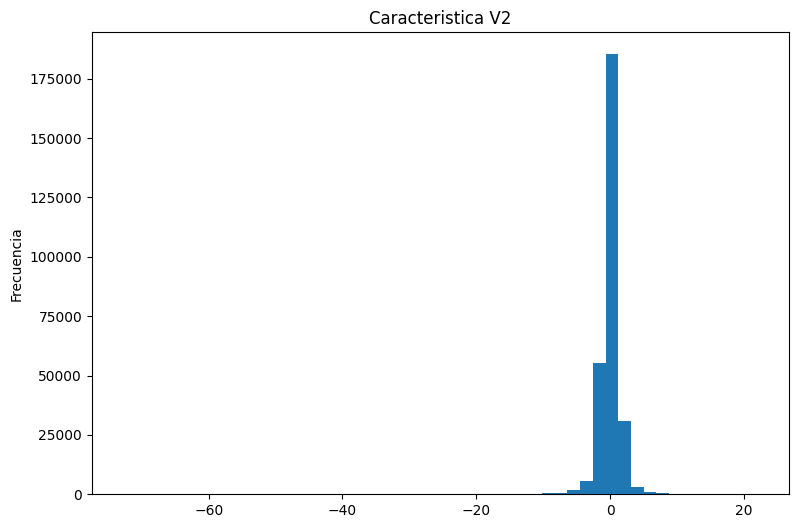

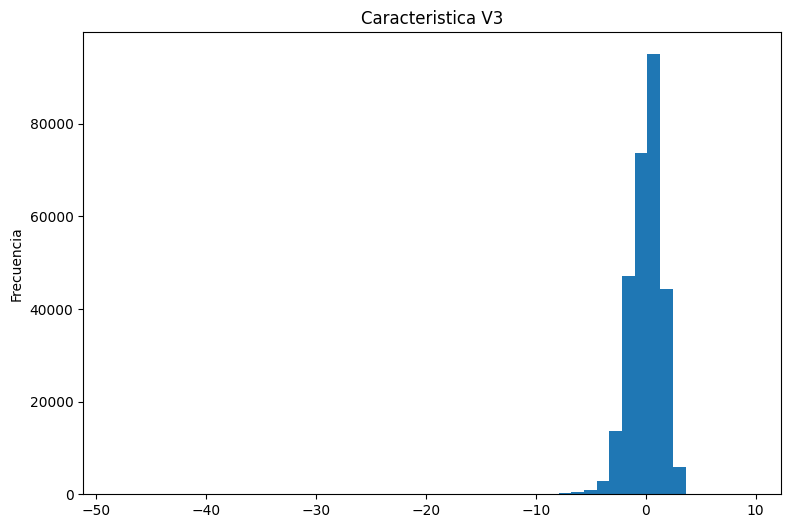

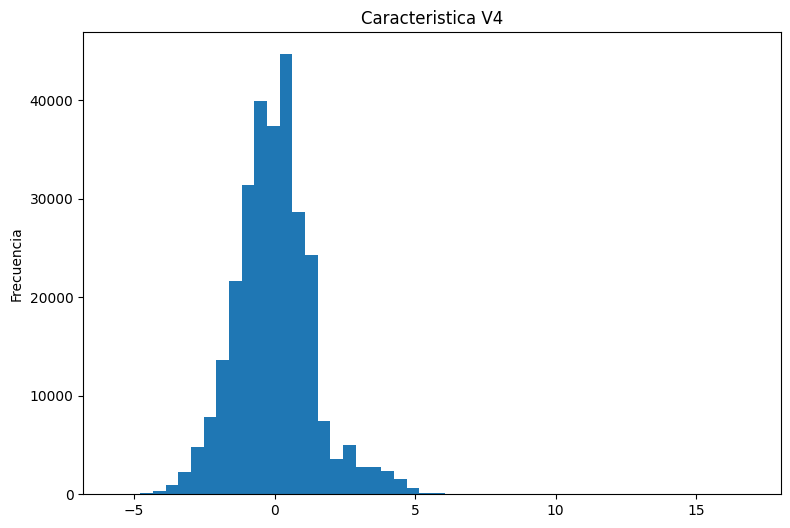

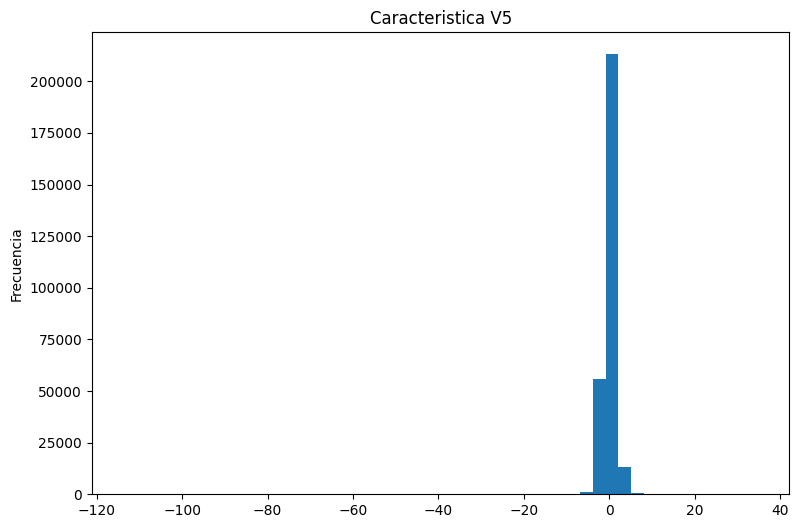

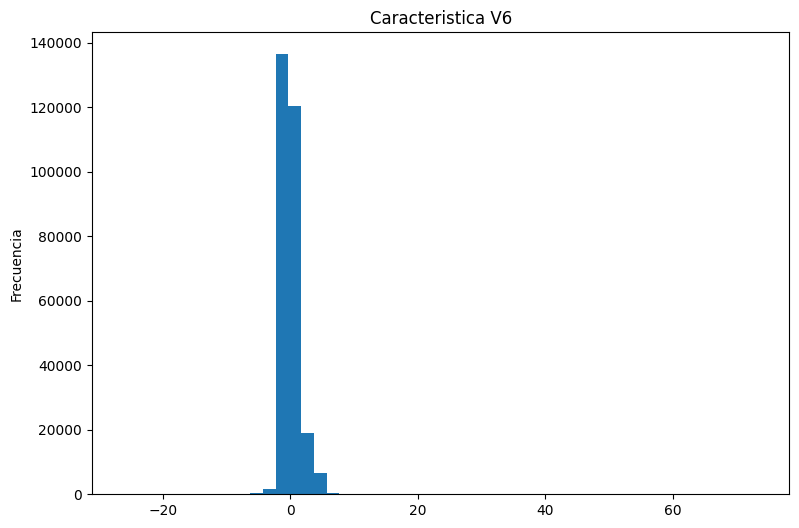

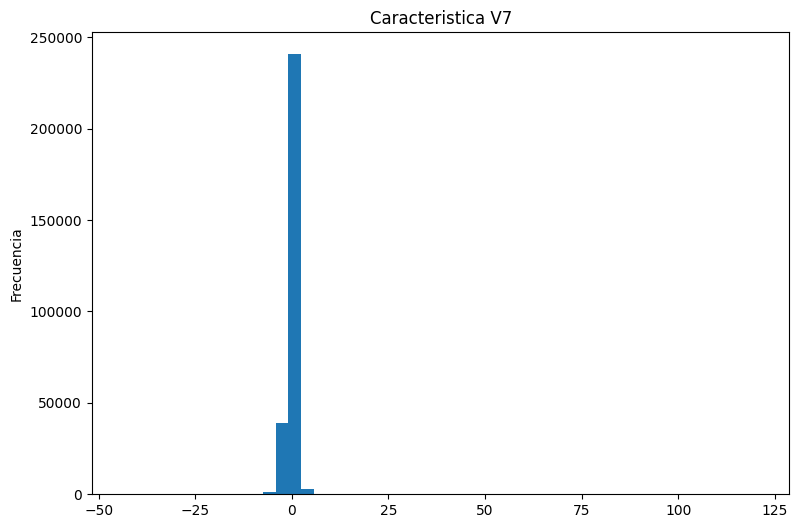

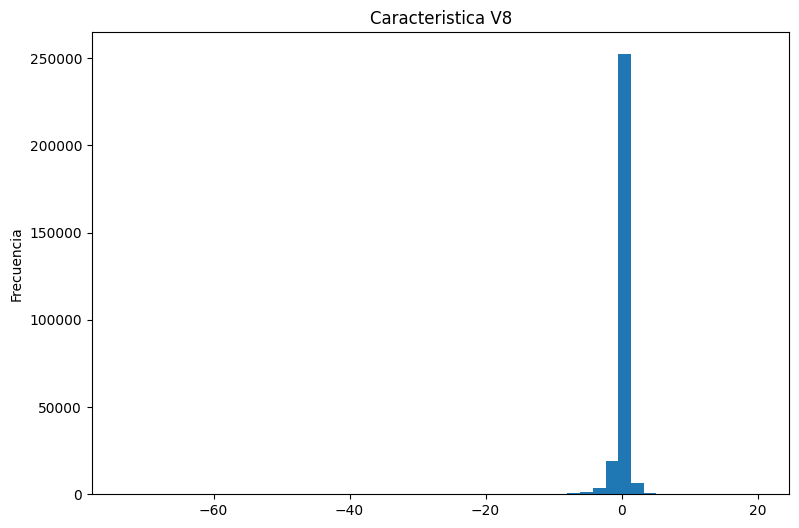

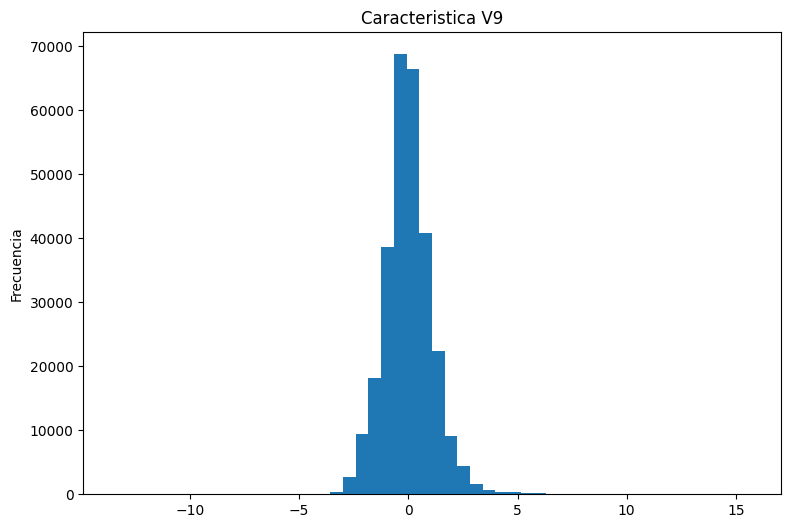

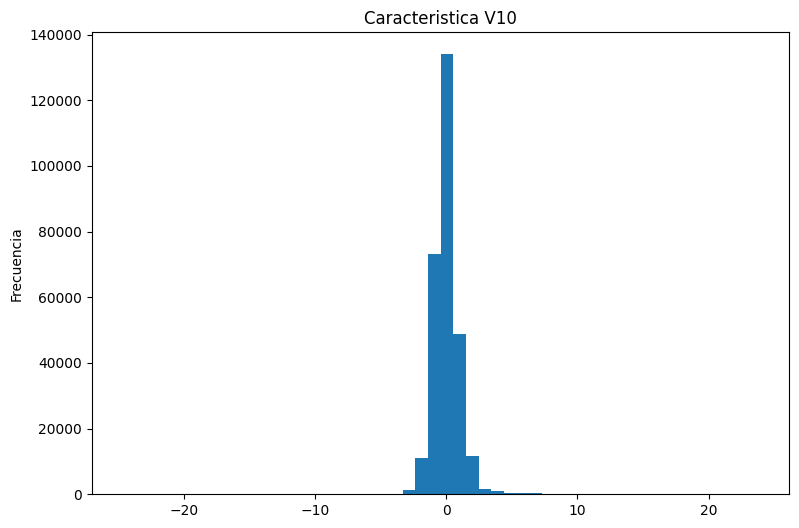

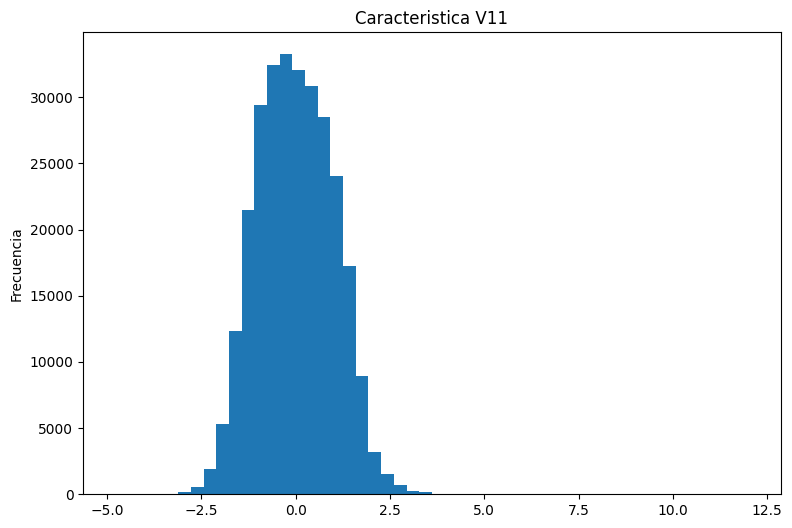

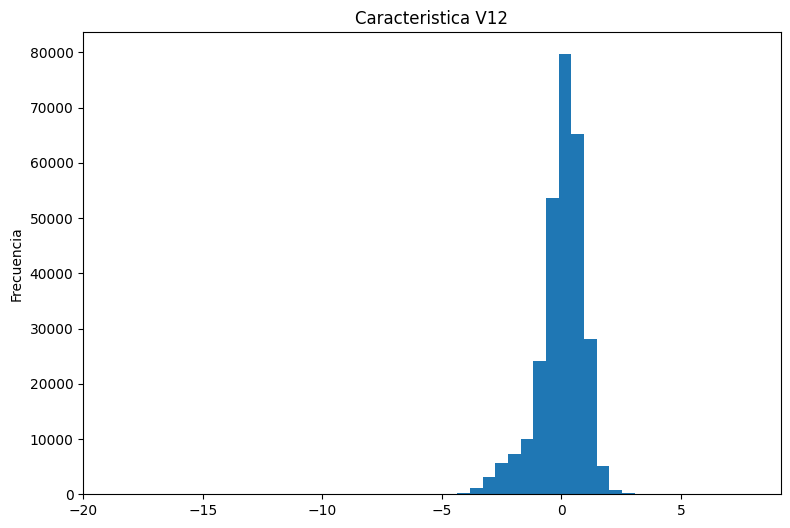

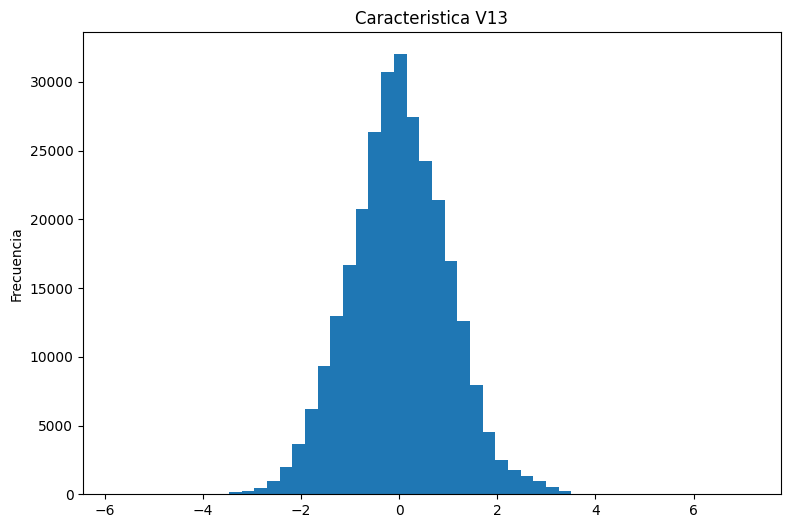

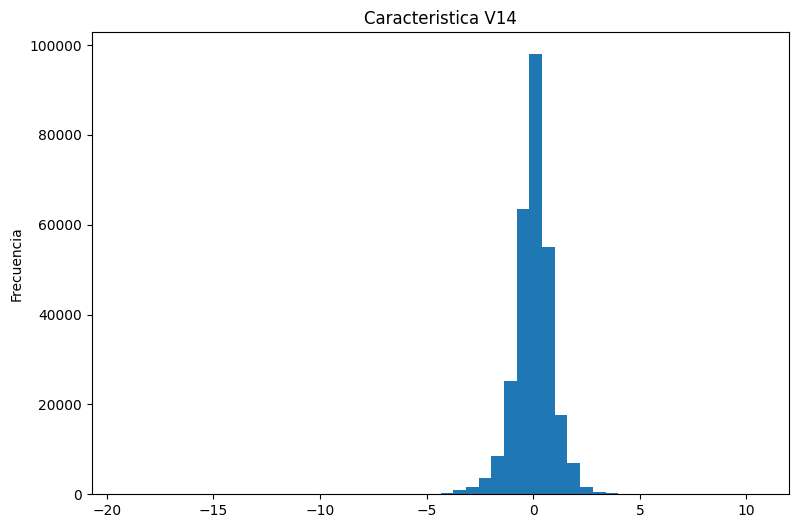

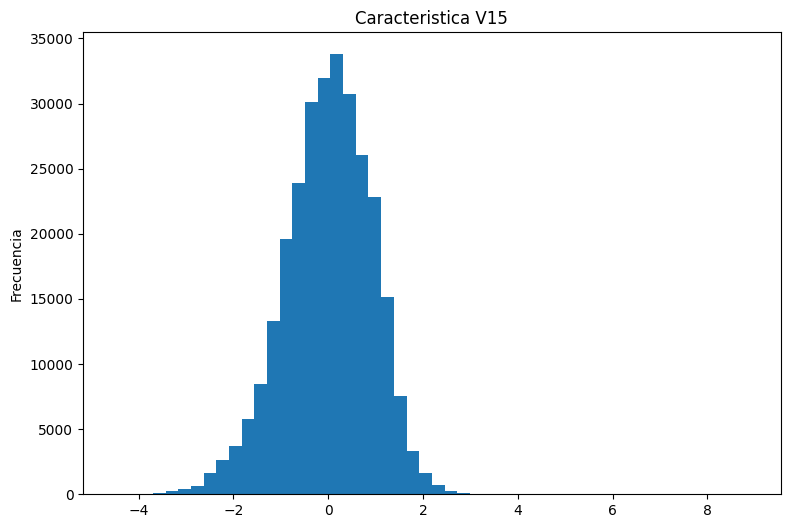

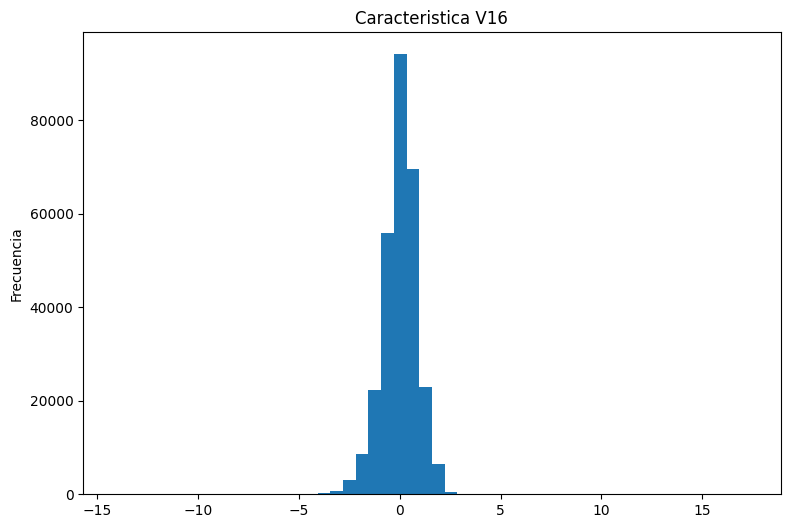

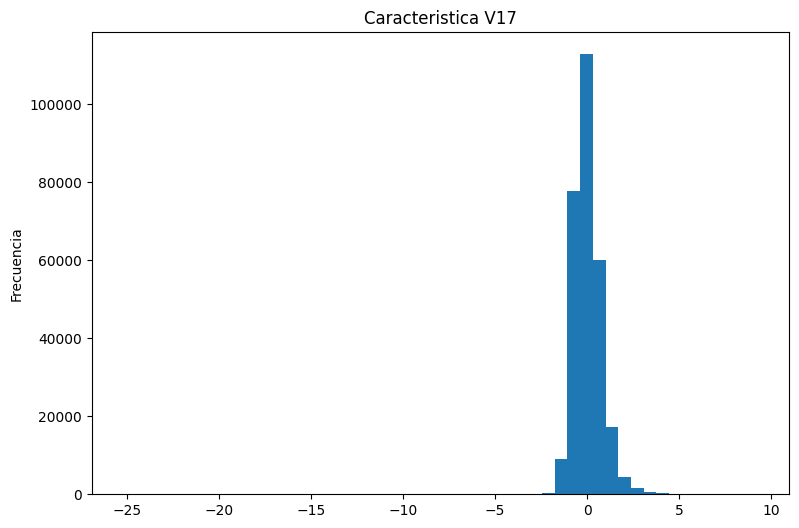

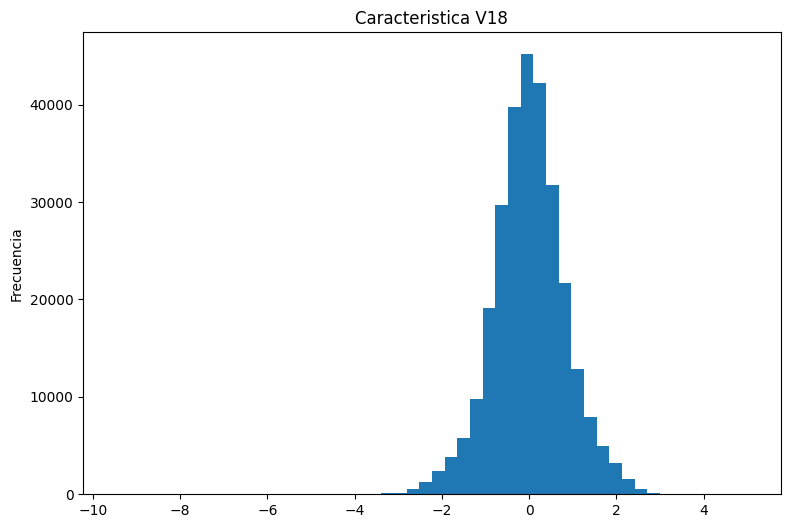

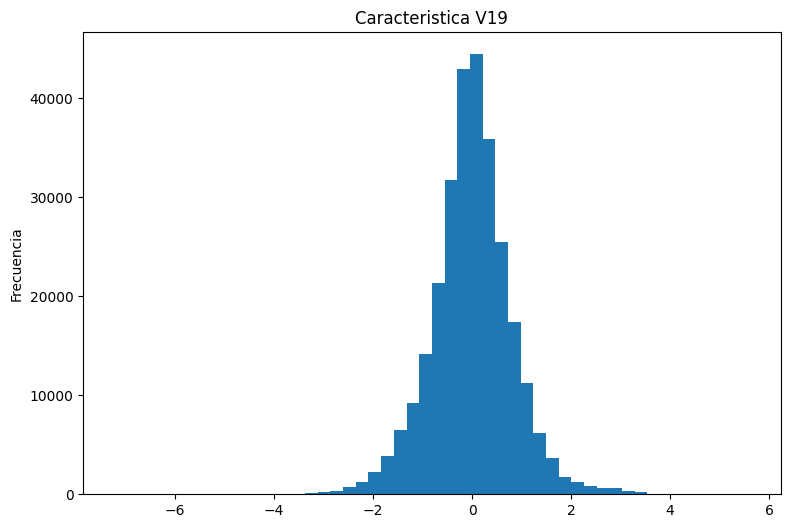

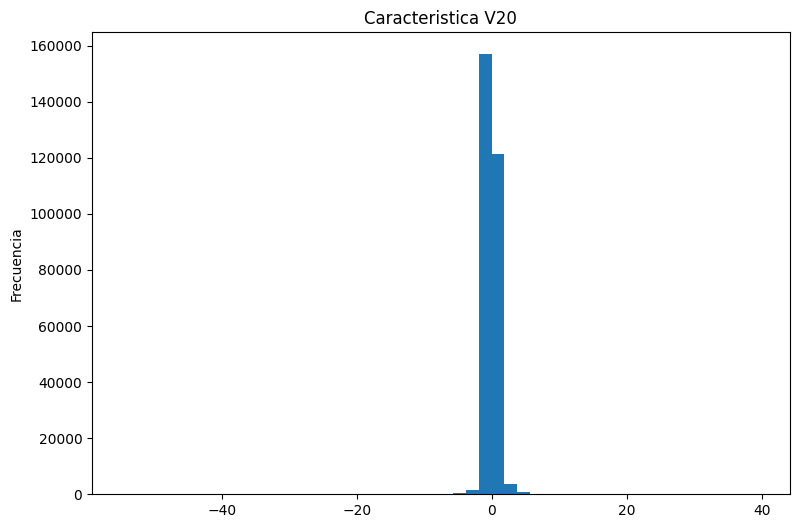

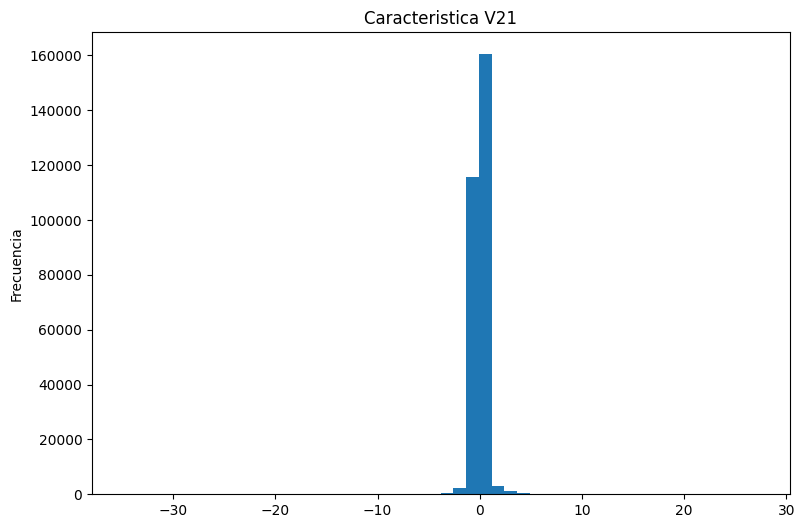

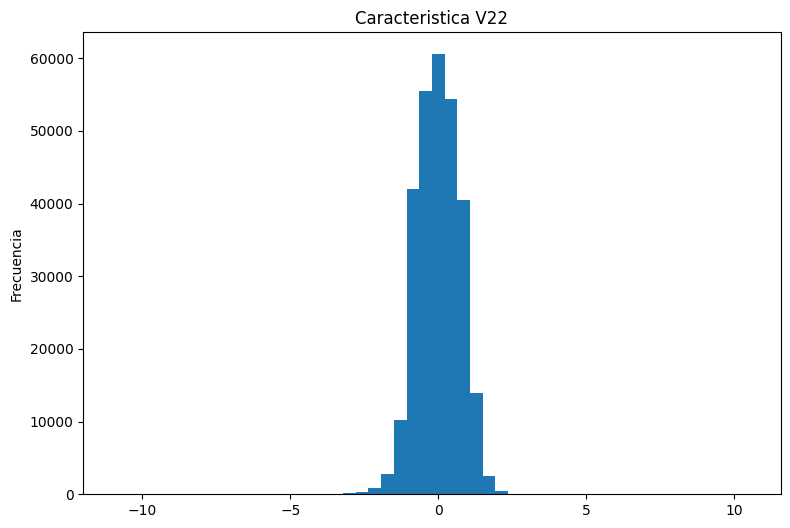

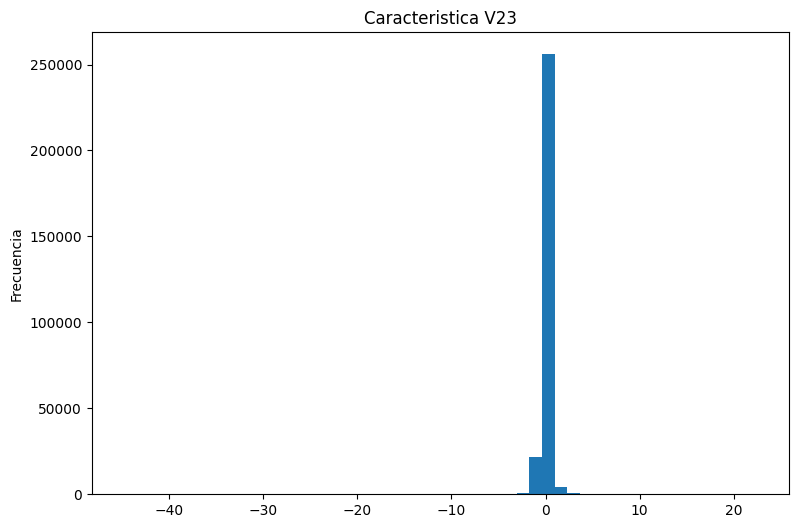

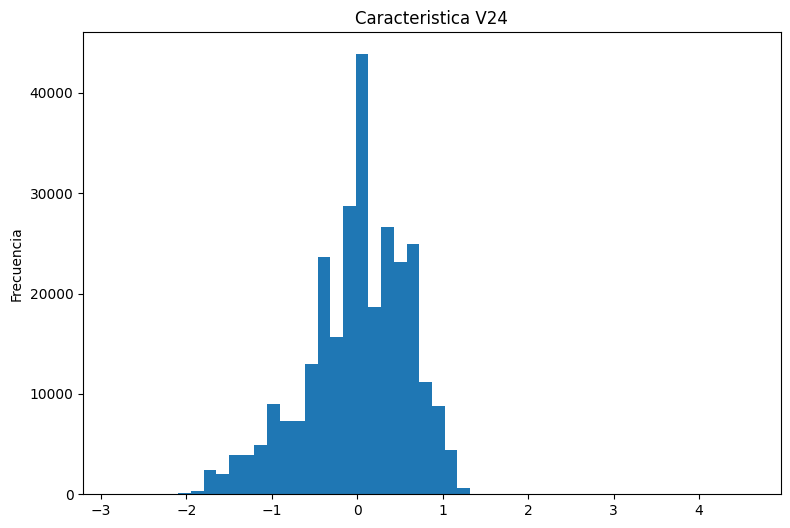

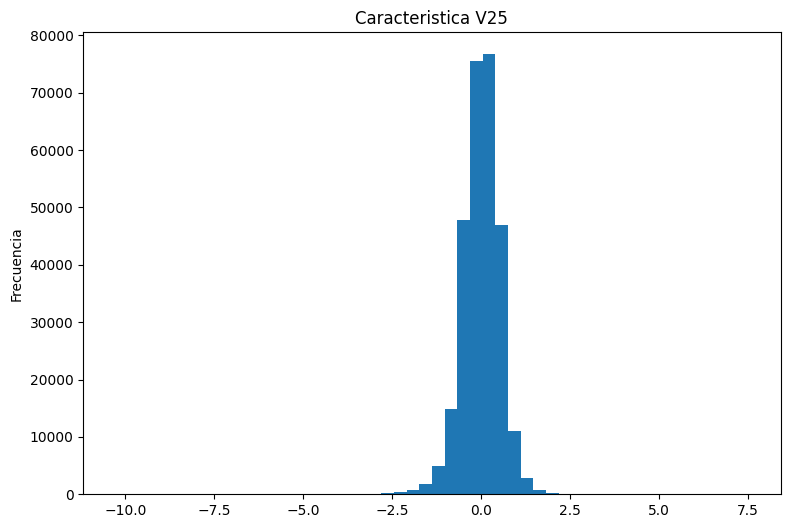

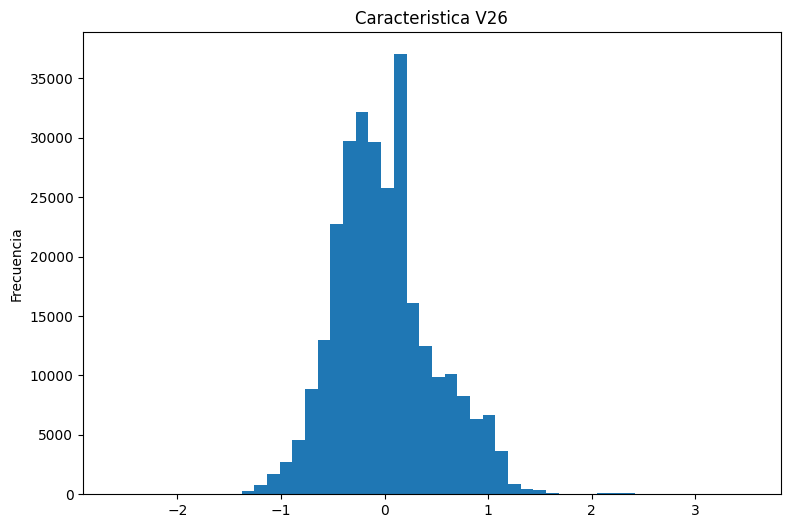

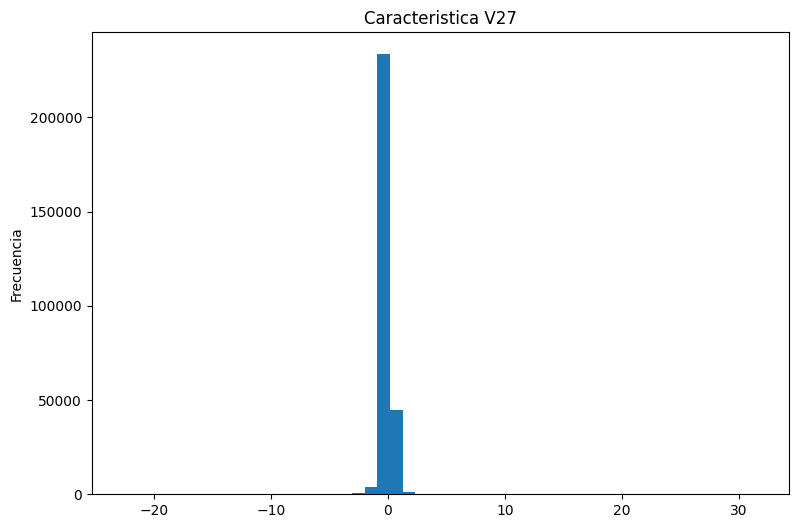

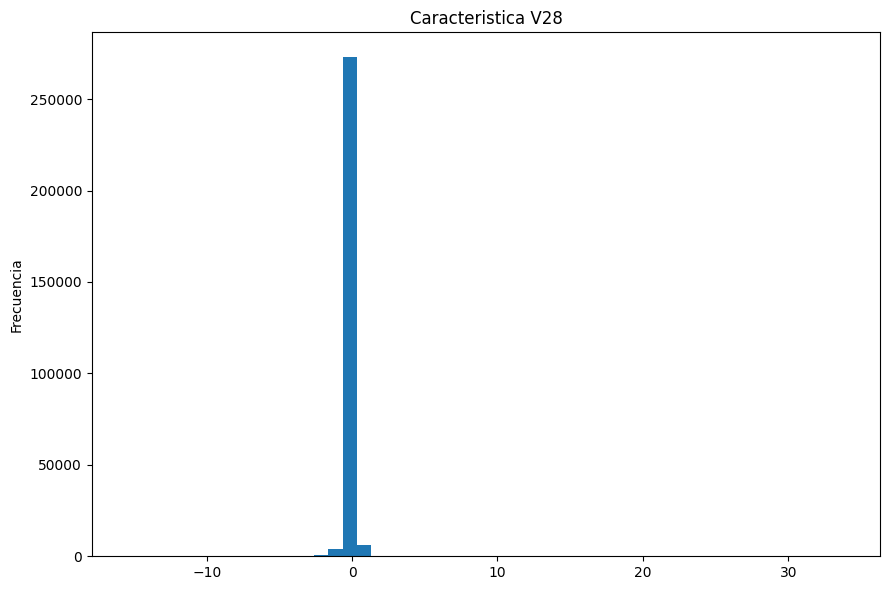

In [14]:
plt.rcParams.update({'figure.max_open_warning': 0})

caracteristicas = fraude_df.iloc[:,1:29].columns

for i, f in enumerate(fraude_df[caracteristicas]):
    fig, ax = plt.subplots(figsize=(9, 6))
    fraude_df[f].hist(bins=50, ax=ax, grid=False)
    ax.set_title("Caracteristica "+f, color='black')
    ax.set_ylabel("Frecuencia")

fig.tight_layout()  
plt.show()

Text(0.5, 1.0, 'Componente principal V4')

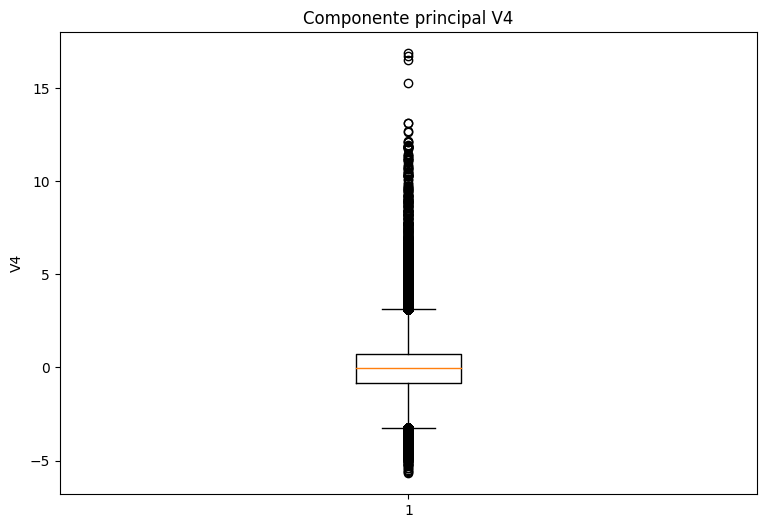

In [15]:
# Gráfico de caja
fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(data=fraude_df, x="V4")

ax.set_ylabel("V4")
ax.set_title("Componente principal V4")

Text(0.5, 1.0, 'V28 vs. V4')

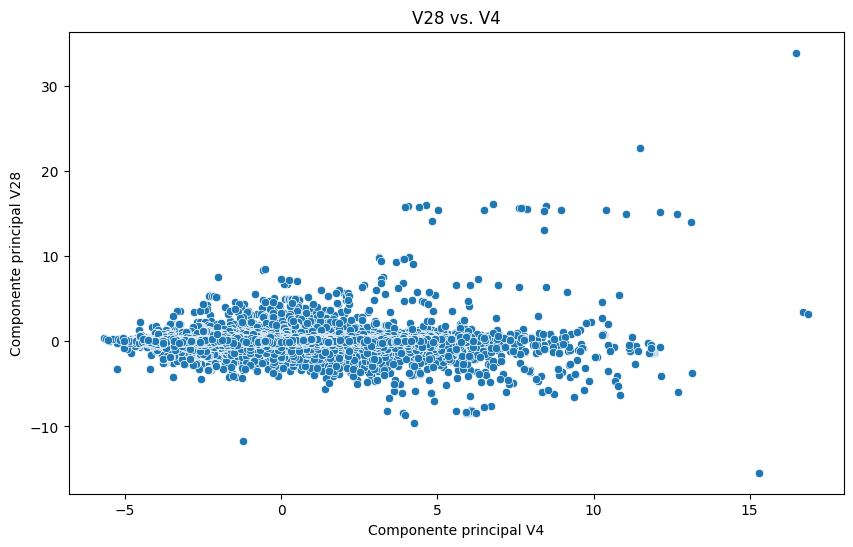

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=fraude_df, x="V4", y="V28", ax=ax)

plt.xlabel("Componente principal V4")
plt.ylabel("Componente principal V28")
plt.title("V28 vs. V4")

### Balanceo y normalización de datos



Para tratar la asimetría que existe entre fraudes y no fraudes en el dataset tomamos una muestra aleatoria del conjunto de transacciones legítimas del mismo tamaño que el conjunto de transacciones fraudulentas. Existen métodos más sofisticados que se analizarán y se tendrán en cuenta más adelante [[2](https://www.aaai.org/Papers/Workshops/2000/WS-00-05/WS00-05-003.pdf), [3](https://ieeexplore.ieee.org/abstract/document/7376606),[10](https://ieeexplore.ieee.org/abstract/document/7376606),[11](https://www.sciencedirect.com/science/article/abs/pii/S0925231220306639),[12](https://www.sciencedirect.com/science/article/abs/pii/S0957417421001913)].

In [17]:
#===============================
# Tratamiento del desequilibrio
#===============================

# Seleccionamos las observaciones fraudulentas
obs_fraudulenta = fraude_df.loc[fraude_df['Class']==1]

# Elegimos una muestra aleatoria de observaciones legitimas del mismo tamaño que las fraudulentas
obs_legitimas = fraude_df.loc[fraude_df['Class']==0].sample(n=obs_fraudulenta.shape[0], random_state=7)

# Definimos nuestro nuevo dataset
fraude_df_equilibrado = obs_fraudulenta.append(obs_legitimas)

In [18]:
# Imprimimos por pantalla las primeras líneas del dataset equilibrado
fraude_df_equilibrado.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [19]:
# Imprimimos por pantalla las últimas líneas del dataset equilibrado
fraude_df_equilibrado.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
259245,159027.0,1.792663,-0.045046,-1.948241,1.356496,0.481150,-1.361523,1.020553,-0.568261,-0.220205,...,0.215496,0.445274,-0.133709,0.003008,0.418642,-0.497243,-0.052997,-0.038930,144.00,0
273789,165700.0,1.842397,-0.521205,-4.030779,-0.621478,3.093832,2.703975,0.611700,0.385760,-0.096242,...,0.378423,0.868133,-0.308482,0.788056,0.810346,0.127778,-0.085250,-0.066571,149.46,0
196526,131551.0,2.079355,-0.964040,-0.644904,-0.483380,-0.875012,-0.318129,-0.786615,-0.110378,-0.022971,...,-0.642962,-1.365374,0.387561,-0.761005,-0.665203,0.272898,-0.021209,-0.037681,54.75,0
104629,69159.0,-1.089481,1.733716,0.366194,0.605195,0.264696,-0.390320,0.416644,0.243195,-0.456449,...,0.106197,0.368343,-0.257293,-0.416972,-0.011827,-0.288130,0.144697,0.196451,0.88,0
26700,34213.0,0.637783,-1.342133,0.129797,0.601724,-0.850978,0.549670,-0.290996,0.231801,-1.130368,...,-0.056718,-0.355168,-0.188398,-0.343582,0.168311,-0.312919,0.012889,0.060823,300.00,0


In [20]:
# Número de filas y columnas del dataset equilibrado
fraude_df_equilibrado.shape

(984, 31)

Clase Observaciones 

1    492
0    492
Name: Class, dtype: int64


Text(0.5, 1.0, 'Comparacion de numero de transacciones fraudulentas (1) vs. no fraudulentas (0)')

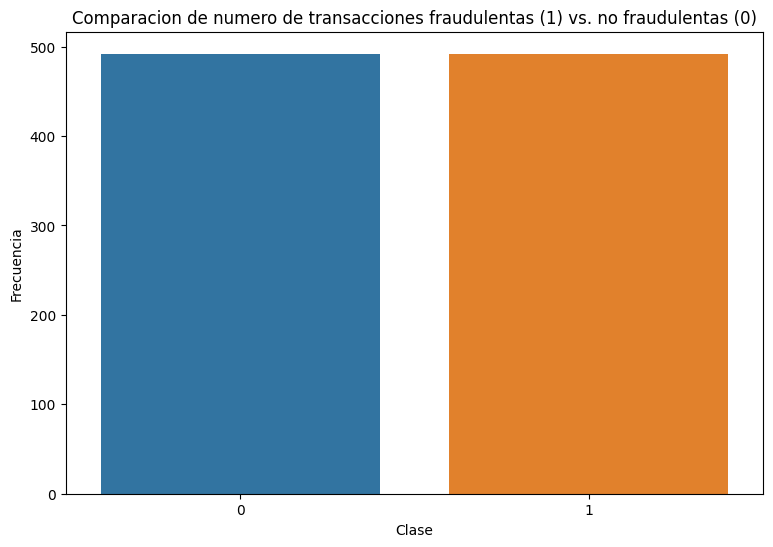

In [21]:
#Comprobamos que el numero de observaciones de transacciones legitimas y fraudulentas es el mismo
print("Clase","Observaciones", "\n")
print(fraude_df_equilibrado['Class'].value_counts())

#Gaaficamos para que sea mas intuitivo
fig, ax = plt.subplots(figsize=(9, 6))
ax = sns.countplot(data=fraude_df_equilibrado, x="Class")

ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
ax.set_title("Comparacion de numero de transacciones fraudulentas (1) vs. no fraudulentas (0)")

In [22]:
#=======================================
# Normalizacion del dataset equilibrado
#=======================================

#Importamos el modulo StandardScaler de scikit-learn para normalizar
from sklearn.preprocessing import StandardScaler

# Separamos el dataframe equilibrado en una matriz de caracterisiticas X y un vector objetivo y.

X = fraude_df_equilibrado.drop(['Class'], axis = 1)
y = fraude_df_equilibrado['Class']

# Guardamos los nombres de las columnas de las variables
columnas_caracteristicas = X.columns

# Normalizamos la matriz X
escalador = StandardScaler()
X_normalizada = escalador.fit_transform(X)

# Pasamos matriz X como un dataframe de pandas
X_normalizada = pd.DataFrame(X_normalizada, columns=columnas_caracteristicas)

X_normalizada.head()

ModuleNotFoundError: No module named 'sklearn'

Al realizar una reducción del dataset, lo que se espera es que la correlación entre las variables cambie. Para comprobar esto, armamos la matriz de correlación del dataset equilibrado.

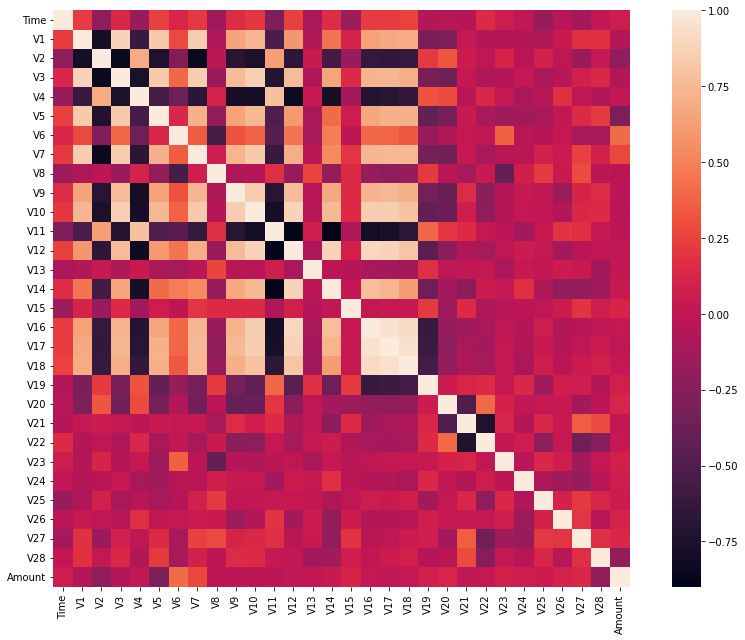

In [22]:
corr_df_balanceado = X_normalizada.corr()
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(corr_df_balanceado, vmax=1.0, square = True)
plt.tight_layout()

Observamos que las características que van de V1 a V18 están correlacionadas lo que indica que existen variables redundantes. Tomamos estas variables para continuar con el análisis aunque se podría hacer un PCA sobre estas para reducir incluso más el número de dimensiones.

## Implementación y evaluación de algoritmos de aprendizaje automático

### Modelos a utilizar

Siguiendo la idea de Niu [[9](https://arxiv.org/abs/1904.10604)], se aplicarán 6 modelos de clasificación supervisados:

- Logistic Regression (LR)
- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- Decision Tree (DT)
- Random Forest (RF)
- Extreme Gradient Boosting (XGB)

y 4 modelos de detección de anomalías no supervisados

- One-Class SVM (OCSVM)
- Auto-Encoder (AE)
- Restricted Boltzmann Machine (RBM)
- Generative Adversarial Networks (GAN)

### Evaluación de los modelos

El rendimiento de los algoritmos se hará en términos de Área Bajo las Curvas de Operación del Receptor (AUROC) [[AUROC_WIKI](https://es.wikipedia.org/wiki/Curva_ROC)].

## Regresión logística (LR)

El primer modelo que analizamos es el de regresion logística [[LR_WIKI](https://es.wikipedia.org/wiki/Regresi%C3%B3n_log%C3%ADstica), [LR_IBM](https://www.ibm.com/ar-es/topics/logistic-regression)].

## K-Nearest Neighbors (KNN)

Uno de los métodos de aprendizaje automático que analizaremos y evaluaremos es el de K-Nearest Neighbors (KNN) que corresponde a un algoritmo de clasificación supervisado [[KNN_WIKI](https://es.wikipedia.org/wiki/K_vecinos_m%C3%A1s_pr%C3%B3ximos), [KNN_IBM](https://www.ibm.com/ar-es/topics/knn)] . Para realizar su implementación importamos en primer lugar,los módulos que vamos a usar de la librería scikit-learn.